# Numerical

Goal : ดูการกระจายตัว (Distribution) ว่าเบ้ (Skewed) ไหม? มี Outliers ที่ต้องจัดการไหม?

## Data Distribution

In [52]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display


In [53]:
import pandas as pd
from pathlib import Path

# --- Configuration ---
USE_SAMPLE = True
# สมมติว่า Notebook อยู่ในโฟลเดอร์ notebooks/eda/
DATA_DIR = Path('../../data/processed/quality')

def load_data(table_name, sample=True):
    suffix = '_sample' if sample else ''
    file_path = DATA_DIR / f"{table_name}_clean{suffix}.csv"
    print(f"Loading: {file_path.name}")
    return pd.read_csv(file_path)

# 1. Load Data
try:
    orders = load_data('orders', USE_SAMPLE)
    order_products = load_data('order_products_prior', USE_SAMPLE)
except FileNotFoundError as e:
    print(f"Error: ไม่พบไฟล์ข้อมูลที่ {DATA_DIR}. กรุณาเช็ก Path อีกครั้ง")
    raise e

# 2. Integrity Check (สำคัญมาก!)
match_rate = order_products['order_id'].isin(orders['order_id']).mean()
if match_rate < 1.0:
    print(f"⚠️ Warning: ข้อมูลไม่ Match กันอยู่ { (1-match_rate)*100 :.2f}%")

# 3. Merge เพื่อเตรียมทำ Behavioral EDA
df = order_products.merge(orders, on='order_id', how='left')

# 4. Feature engineering: cumulative reorder per customer (ตาม history)
df = df.sort_values(['user_id', 'order_number', 'add_to_cart_order']).reset_index(drop=True)
df['cumulative_reorder_per_customer'] = df.groupby('user_id')['reordered'].cumsum()

print(f"--- Summary ({'Sample' if USE_SAMPLE else 'Full'}) ---")
print(f"Rows: {len(df):,}")
print(f"Missing after join:\n{df.isnull().sum()}")
print("Added column: cumulative_reorder_per_customer")
print(df[['user_id', 'order_number', 'product_id', 'reordered', 'cumulative_reorder_per_customer']].head(10))

Loading: orders_clean_sample.csv
Loading: order_products_prior_clean_sample.csv
--- Summary (Sample) ---
Rows: 9,356
Missing after join:
order_id                             0
product_id                           0
add_to_cart_order                    0
reordered                            0
user_id                              0
eval_set                             0
order_number                         0
order_dow                            0
order_hour_of_day                    0
days_since_prior_order             565
cumulative_reorder_per_customer      0
dtype: int64
Added column: cumulative_reorder_per_customer
   user_id  order_number  product_id  reordered  \
0       52            26       42489          1   
1       52            26       43352          0   
2       52            26       40063          1   
3       52            26        8048          1   
4       52            26       46516          1   
5      551             9       13740          0   
6      551        

In [54]:
palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style="whitegrid")

<Figure size 700x400 with 0 Axes>

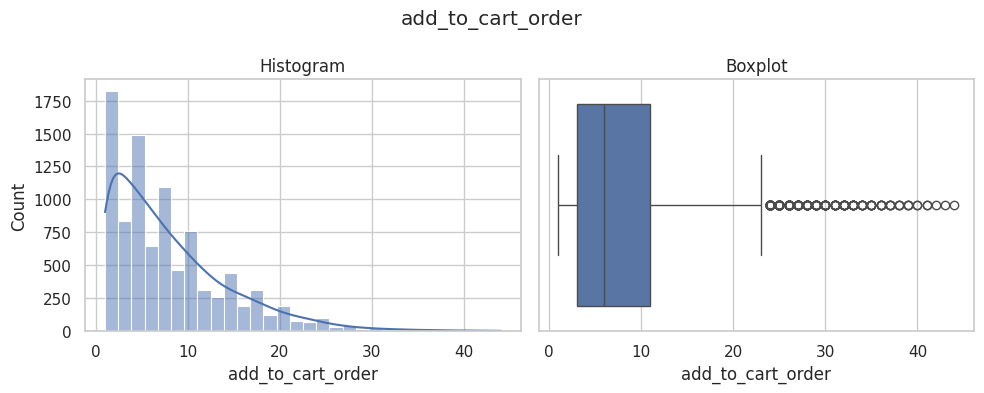

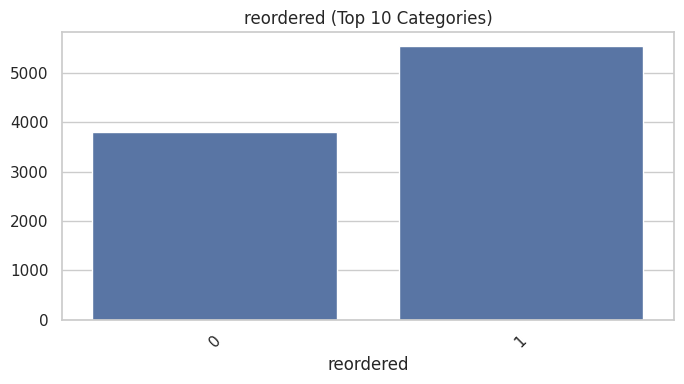

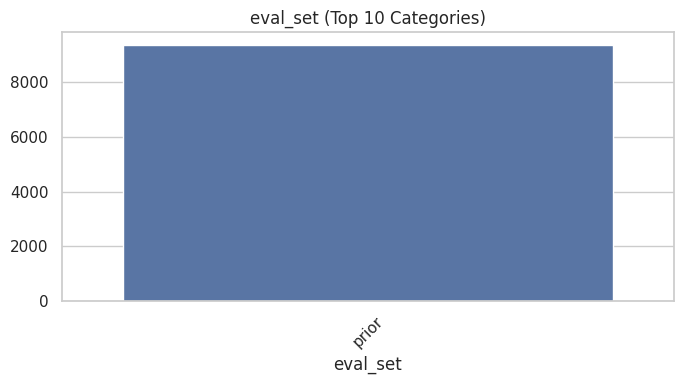

<Figure size 700x400 with 0 Axes>

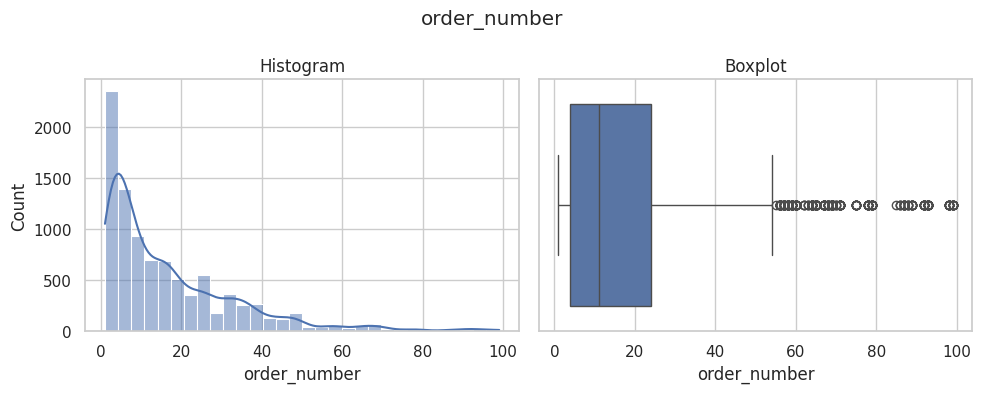

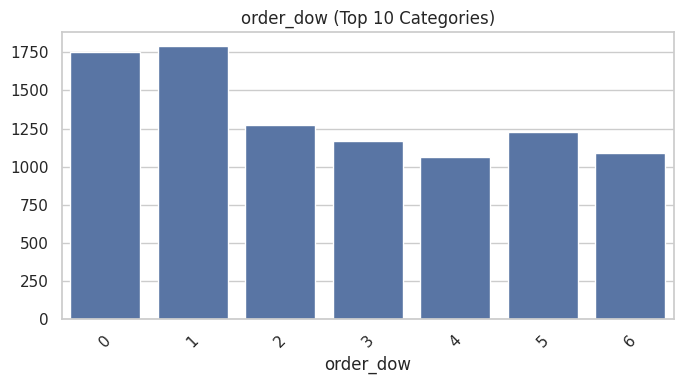

<Figure size 700x400 with 0 Axes>

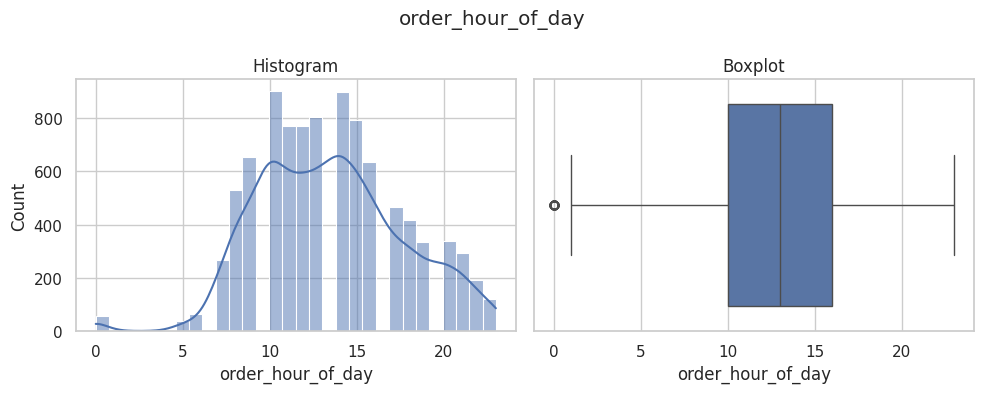

<Figure size 700x400 with 0 Axes>

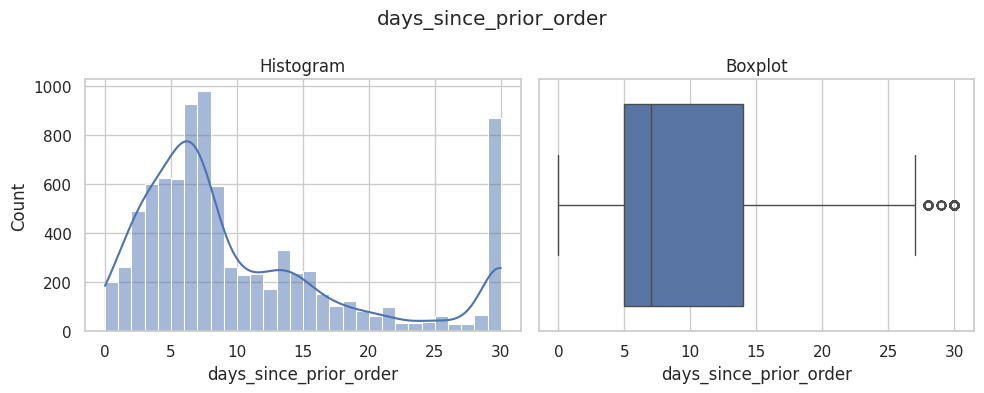

<Figure size 700x400 with 0 Axes>

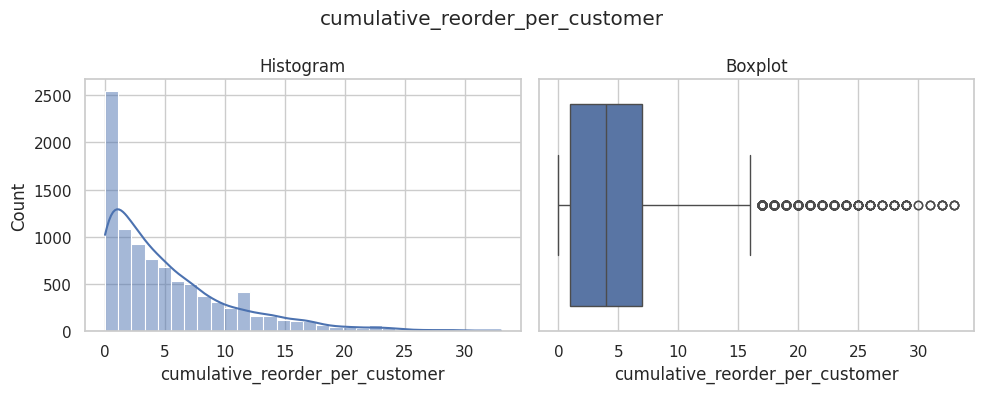

In [55]:
for col in df.columns:
    
    # ❌ ตัด id ออก
    if "id" in col.lower():
        continue

    unique_vals = df[col].nunique()
    plt.figure(figsize=(7, 4))

    # 🟢 CATEGORICAL
    if df[col].dtype == "object" or unique_vals < 10:
        
        # 👉 เอา top 10
        top_vals = df[col].value_counts().nlargest(10)
        
        sns.barplot(x=top_vals.index, y=top_vals.values)
        plt.xticks(rotation=45)
        plt.title(f"{col} (Top 10 Categories)")

    # 🔵 NUMERIC
    elif df[col].dtype in ["int64", "float64"]:
        
        # 🟡 BINARY
        if unique_vals <= 2:
            sns.countplot(x=col, data=df)
            plt.title(f"{col} (Binary)")

        # 🟠 DISCRETE
        elif unique_vals < 20:
            sns.histplot(df[col], bins=min(unique_vals, 15))
            plt.title(f"{col} (Discrete)")

        # 🔴 CONTINUOUS
        else:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            
            sns.histplot(df[col], kde=True, bins=30, ax=axes[0])
            axes[0].set_title("Histogram")

            sns.boxplot(x=df[col], ax=axes[1])
            axes[1].set_title("Boxplot")

            fig.suptitle(col)
            plt.tight_layout()
            plt.show()
            continue

    else:
        plt.close()
        continue

    plt.tight_layout()
    plt.show()

# Bivariate Comparison

## Group Comparison

### reordered vs days_since_prior_order

In [56]:
print("Distribution of days_since_prior_order by Reordered:")
df.groupby("reordered")["days_since_prior_order"].describe()

Distribution of days_since_prior_order by Reordered:


,count,mean,std,min,25%,50%,75%,max
reordered,,,,,,,,
0,3244.0,11.487361,9.35533,0.0,5.0,8.0,16.0,30.0
1,5547.0,9.700559,7.91926,0.0,5.0,7.0,13.0,30.0


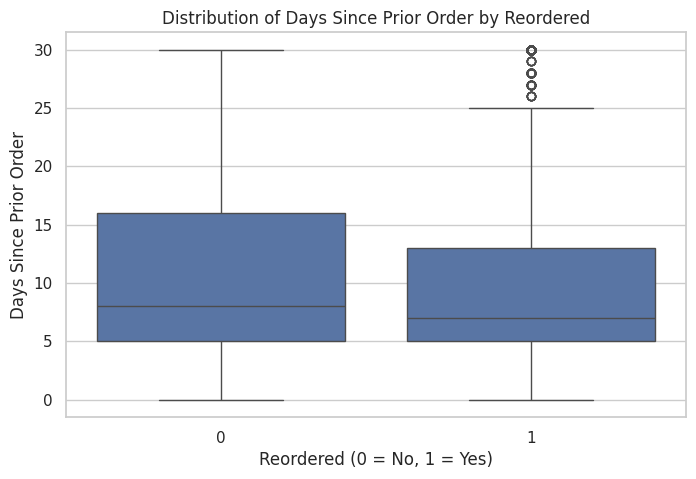

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(x='reordered', y='days_since_prior_order', data=df)
plt.title('Distribution of Days Since Prior Order by Reordered')
plt.xlabel('Reordered (0 = No, 1 = Yes)')
plt.ylabel('Days Since Prior Order')
plt.show()

ค่ากลางของวันเว้นช่วงไม่ได้ต่างกันมากนัก แต่ กลุ่ม reorder มี lower bound สูงกว่า 

แปลว่า คนที่สั่งซ้ำมักไม่สั่งทันทีหลัง order ก่อนหน้า
คนที่ไม่ reorder บางส่วนสั่งเร็ว (1–3 วัน) แต่ไม่ต่อเนื่อง

In [58]:
print("Distribution of Order Number by Reordered:")
df.groupby("reordered")["order_number"].describe()


Distribution of Order Number by Reordered:


,count,mean,std,min,25%,50%,75%,max
reordered,,,,,,,,
0,3809.0,10.410081,12.731341,1.0,2.0,6.0,14.0,99.0
1,5547.0,21.046512,17.561453,2.0,7.0,16.0,31.0,99.0


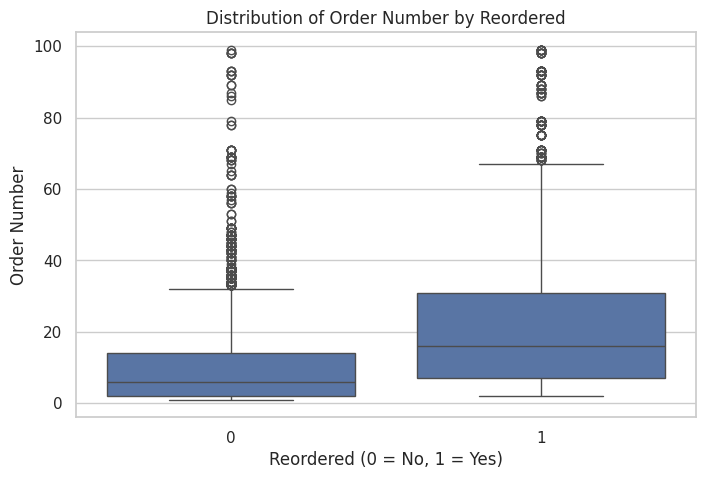

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(x='reordered', y='order_number', data=df)
plt.title('Distribution of Order Number by Reordered')
plt.xlabel('Reordered (0 = No, 1 = Yes)')
plt.ylabel('Order Number')
plt.show()

ค่ากลางของจํานวนต่างอย่างมีนัยสําคัญ ช่วง lowerbond upperbond ต่างกัน ในส่วนคน ที่ reorder มากกว่า คนที่ผมไม่ reorder
แปลว่า คนที่สั่งซ้ำมักซื้อสินค้า สมํ่าเสมอ และ มีแนวโน้มการสั่งซ้ำมากกว่า กลุ่มที่ไม่ Reorder

In [60]:
print("Distribution of Cumulative Reorder per Customer by Reordered:")
df.groupby("reordered")["cumulative_reorder_per_customer"].describe()

Distribution of Cumulative Reorder per Customer by Reordered:


,count,mean,std,min,25%,50%,75%,max
reordered,,,,,,,,
0,3809.0,3.894460,5.152393,0.0,0.0,2.0,6.0,33.0
1,5547.0,6.235443,5.253998,1.0,2.0,5.0,9.0,33.0


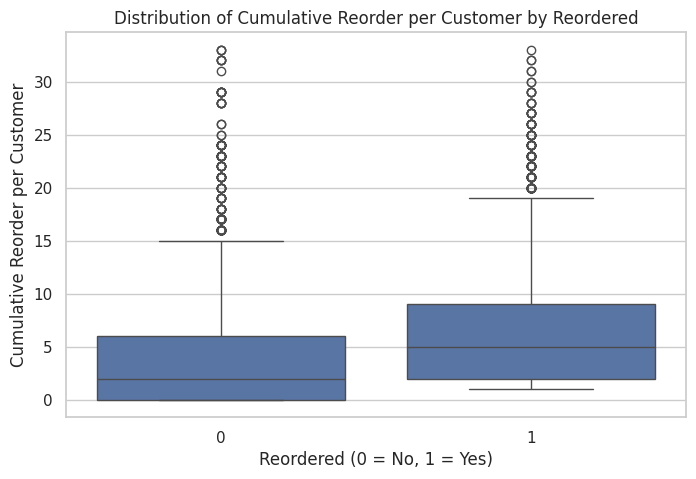

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x='reordered', y='cumulative_reorder_per_customer', data=df)
plt.title('Distribution of Cumulative Reorder per Customer by Reordered')
plt.xlabel('Reordered (0 = No, 1 = Yes)')
plt.ylabel('Cumulative Reorder per Customer')
plt.show()

ค่ากลางของจํานวนเพิ่มจํานวนการสั่งซื้อซํ้า ต่างอย่างมีนัยสําคัญ ช่วง lowerbond upperbond ต่างกัน ในส่วนคน ที่ reorder มากกว่า คนที่ผมไม่ reorder
แปลว่า คนที่ reorder มีการ ซื้อสินค้า ซํ้า คือ กับมาซื้อชิ้นเดิมอีกครั้ง มากกว่า กลุ่มคนที่ ไมี reorder

### Distribution Comparison

### Correlation (numeric vs numeric)

### Categorical vs Categorical